### 1. Import data

In [28]:
import pandas as pd

#Import data 
data = pd.read_csv("road_accident_dataset.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      132000 non-null  object 
 1   Year                         132000 non-null  int64  
 2   Month                        132000 non-null  object 
 3   Day of Week                  132000 non-null  object 
 4   Time of Day                  132000 non-null  object 
 5   Urban/Rural                  132000 non-null  object 
 6   Road Type                    132000 non-null  object 
 7   Weather Conditions           132000 non-null  object 
 8   Visibility Level             132000 non-null  float64
 9   Number of Vehicles Involved  132000 non-null  int64  
 10  Speed Limit                  132000 non-null  int64  
 11  Driver Age Group             132000 non-null  object 
 12  Driver Gender                132000 non-null  object 
 13 

### 2. Select Features

In [29]:
# List of columns to keep
columns_to_keep = [
    "Speed Limit",
    "Driver Alcohol Level",
    "Traffic Volume",
    "Population Density",
    "Visibility Level"
]

# Select only the desired columns
data_cleaned = data[columns_to_keep].copy()
data_cleaned.info()
data_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Speed Limit           132000 non-null  int64  
 1   Driver Alcohol Level  132000 non-null  float64
 2   Traffic Volume        132000 non-null  float64
 3   Population Density    132000 non-null  float64
 4   Visibility Level      132000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 5.0 MB


,Speed Limit,Driver Alcohol Level,Traffic Volume,Population Density,Visibility Level
0,37,0.051921,7412.752760,3866.273014,220.414651
1,96,0.234893,4458.628820,2333.916224,168.311358
2,62,0.142366,9856.915064,4408.889129,341.286506
3,78,0.120815,4958.646267,2810.822423,489.384536
4,98,0.155842,3843.191463,3883.645634,348.344850


### 3. Check correlation 

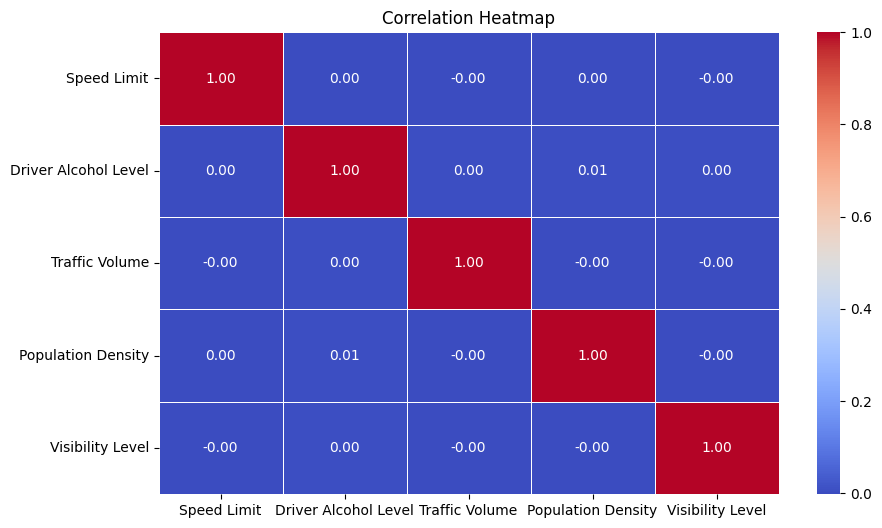

                      Speed Limit  Driver Alcohol Level  Traffic Volume  Population Density  Visibility Level
Speed Limit              1.000000              0.000760       -0.001970            0.001393         -0.002504
Driver Alcohol Level     0.000760              1.000000        0.003478            0.005116          0.002469
Traffic Volume          -0.001970              0.003478        1.000000           -0.001889         -0.002471
Population Density       0.001393              0.005116       -0.001889            1.000000         -0.000137
Visibility Level        -0.002504              0.002469       -0.002471           -0.000137          1.000000


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
corr = data_cleaned.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Compute correlation table
print(corr.to_string())


### 4. Feature Scaling using Standardization

In [31]:
from sklearn.preprocessing import StandardScaler

# Standardize numerical features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_cleaned)

#Convert back to DataFrame for easier handling
scaled_data_df = pd.DataFrame(scaled_data, columns=data_cleaned.columns)
scaled_data_df.info()
scaled_data_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Speed Limit           132000 non-null  float64
 1   Driver Alcohol Level  132000 non-null  float64
 2   Traffic Volume        132000 non-null  float64
 3   Population Density    132000 non-null  float64
 4   Visibility Level      132000 non-null  float64
dtypes: float64(5)
memory usage: 5.0 MB


,Speed Limit,Driver Alcohol Level,Traffic Volume,Population Density,Visibility Level
0,-1.443928,-1.015039,0.828768,0.943883,-0.420434
1,0.825185,1.518343,-0.203904,-0.119780,-0.821466
2,-0.482439,0.237229,1.683173,1.320532,0.509899
3,0.132914,-0.061158,-0.029113,0.211258,1.649789
4,0.902104,0.423813,-0.419042,0.955942,0.564226


### 5. Elbow Method to Determine Number of Clusters

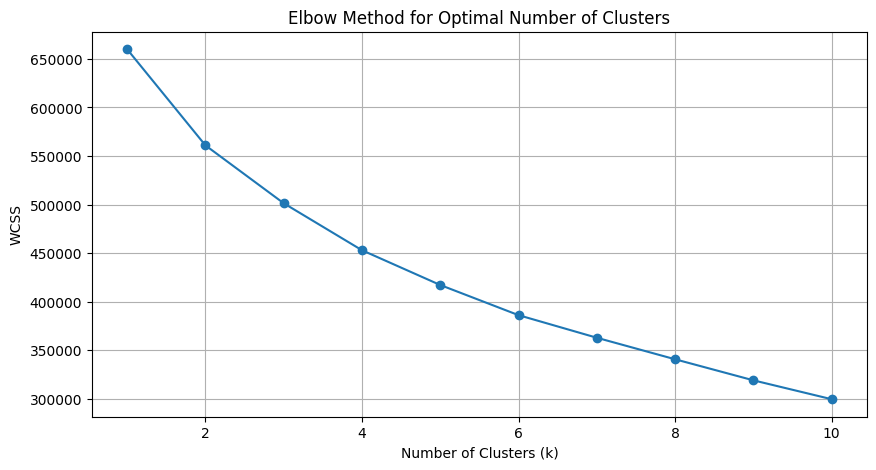

Optimal number of clusters (elbow point): 4


In [32]:
from sklearn.cluster import KMeans

wcss = []
K = range(1, 11) 

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data_df)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot WCSS
plt.figure(figsize=(10,5))
plt.plot(K, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.grid(True)
plt.show()

#Elbow detection using Kneedle
from kneed import KneeLocator
kl = KneeLocator(K, wcss, curve="convex", direction="decreasing")
optimal_k = kl.elbow
print("Optimal number of clusters (elbow point):", optimal_k)


### 6. K-Means Clustering

Cluster
0    33105
2    33021
3    32976
1    32898
Name: count, dtype: int64


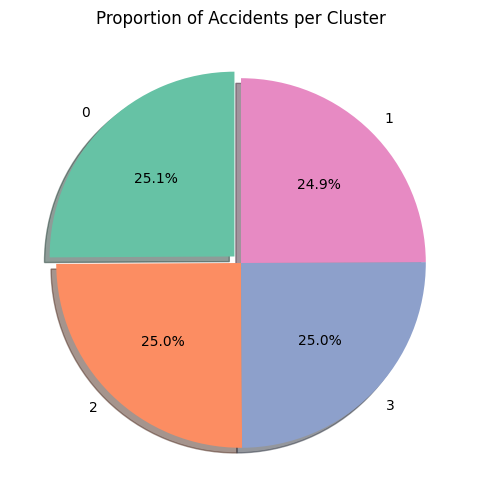

In [33]:
from sklearn.cluster import KMeans
import seaborn as sns
# Number of clusters = 4
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data_df)

# Add cluster labels to original cleaned dataset
data_cleaned['Cluster'] = cluster_labels

# Check number of points per cluster
print(data_cleaned['Cluster'].value_counts())

# Calculate cluster counts
cluster_counts = data_cleaned['Cluster'].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(cluster_counts.values,
        labels=cluster_counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette("Set2"),
        startangle=90,
        explode=[0.05 if i==cluster_counts.idxmax() else 0 for i in cluster_counts.index],
        shadow=True)
plt.title("Proportion of Accidents per Cluster")
plt.show()



### 7. Performance Metrics

In [24]:
from sklearn.metrics import silhouette_score
# Take sample from scaled data for silhouette score calculation
scaled_sample = scaled_data_df.sample(n=10000, random_state=42)

# Get the corresponding cluster labels
sample_labels = data_cleaned.loc[scaled_sample.index, 'Cluster']

sil_score = silhouette_score(scaled_sample, sample_labels)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.14119783365898744


### 8. Average Feature Values by Cluster

In [34]:
cluster_profiles = data_cleaned.groupby("Cluster")[columns_to_keep].mean()
print(cluster_profiles.to_string())


         Speed Limit  Driver Alcohol Level  Traffic Volume  Population Density  Visibility Level
Cluster                                                                                         
0          53.571183              0.056347     5047.042566         2576.116119        273.209171
1          95.953189              0.130049     5016.900972         3869.975837        274.535943
2          95.620787              0.121542     5060.670232         1133.662160        274.839449
3          53.135038              0.193276     5042.997841         2450.976892        277.576780


### 9. Radar Chart

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_24732\2710335655.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


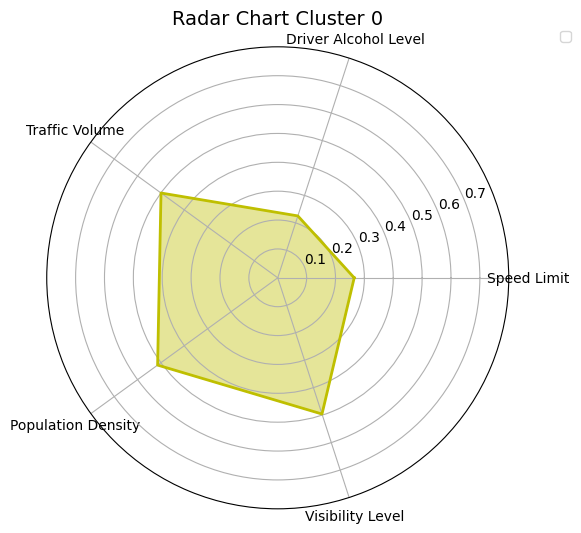

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_24732\2710335655.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


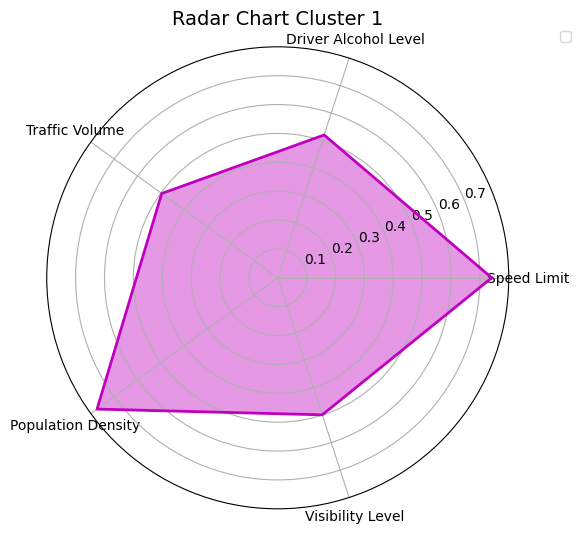

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_24732\2710335655.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


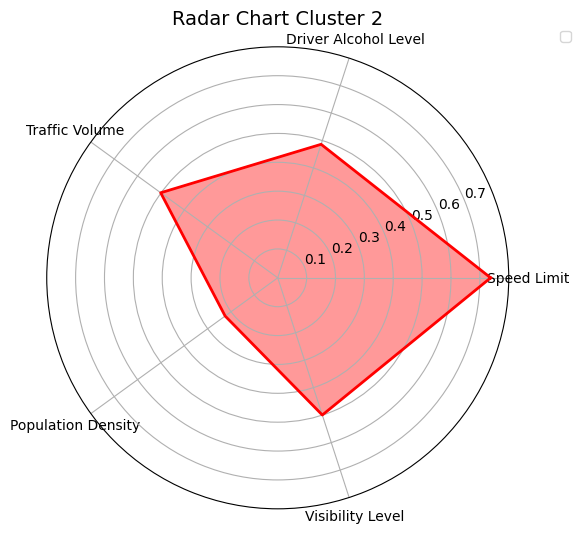

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_24732\2710335655.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


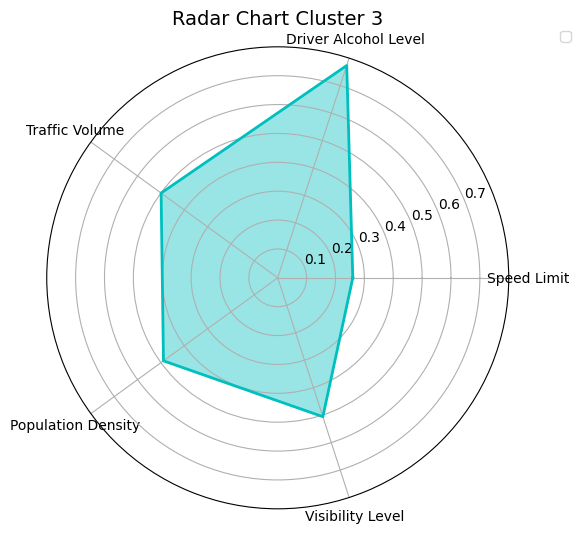

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Scale 0–1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_cleaned[columns_to_keep])

scaled_df = pd.DataFrame(scaled, columns=columns_to_keep)
scaled_df['Cluster'] = data_cleaned['Cluster']

# Mean for radar
cluster_means = scaled_df.groupby('Cluster')[columns_to_keep].mean()

# Radar setup
N = len(columns_to_keep)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close loop

# Radial ticks
radial_ticks = [0.1,0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
colors = ['y', 'm', 'r', 'c']  


# Create 1 radar chart per cluster
for cluster in cluster_means.index:
    values = cluster_means.loc[cluster].tolist()
    values += values[:1]

    plt.figure(figsize=(8, 6))
    ax = plt.subplot(111, polar=True)

    # Set radial scale 0.2 to 0.8
    ax.set_ylim(0.0, 0.8)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([str(t) for t in radial_ticks])

    # Plot + fill
    color = colors[cluster % len(colors)]  # cycle colors if >6 clusters
    ax.plot(angles, values, linewidth=2, color=color)
    ax.fill(angles, values, color=color, alpha=0.4)  # stronger fill
    #ax.plot(angles, values, linewidth=2,)
    #ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(columns_to_keep)

    plt.title(f"Radar Chart Cluster {cluster}", fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))

    plt.show()
